# **Практическая работа №2. Использование глубоких нейронных сетей для решения задач регрессии и классификации**



## **Задание №1. Обучение модели ИНС для решения задачи регрессии**



Постройте глубокую нейронную сеть для предсказания цен на недвижимость в городе Бостон, используя датасет датасет boston_housing_price

[Описание датасета](https://www.hackersrealm.net/post/boston-house-price-prediction-analysis-using-python)

#### 1.1. Загружаем исходные данные:

In [ ]:
import pandas as pd
import numpy as np

data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep="\\s+", skiprows=22, header=None)
X = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
y = raw_df.values[1::2, 2]

#### 1.2. Проектируем архитектуру для этой задачи

In [ ]:
from keras.models import Sequential
from keras.layers import Dense

model = Sequential()
model.add(Dense(64, activation="relu", input_shape=(X.shape[1],)))
model.add(Dense(64, activation="relu"))
model.add(Dense(32, activation="relu"))
model.add(Dense(1))
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


#### 1.3. Компилируем модель ИНС

Подберите нужную функцию потерь и метрику.

In [ ]:
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)


#### 1.4. Обучаем модель ИНС

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# разбиваем данные
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# нормализуем
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# обучаем
history = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=1
)


Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 66ms/step - loss: 628.1326 - mae: 23.1323 - val_loss: 526.1847 - val_mae: 21.3549
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 548.2881 - mae: 21.4233 - val_loss: 474.4190 - val_mae: 20.0335
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 482.7520 - mae: 19.7727 - val_loss: 398.7591 - val_mae: 17.9122
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 422.0880 - mae: 17.6775 - val_loss: 288.4760 - val_mae: 14.8158
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 289.3317 - mae: 14.4318 - val_loss: 163.9217 - val_mae: 10.9370
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 165.7981 - mae: 10.9899 - val_loss: 71.6445 - val_mae: 6.5081
Epoch 7/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - loss: 79.7067 - mae: 7.2598 - val_loss: 45.6177 - val_mae: 4.9768
Epoch 8/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - loss: 62.6658 - mae: 6.3474 - val_loss: 35.8295 - val_mae: 4.2282
Epoch 9/100
11/11 

#### 1.6. Делаем предсказания на тестовых данных

In [ ]:
y_pred = model.predict(X_test_scaled).flatten()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


#### 1.7. Вычисляем метрику качества на тестовых данных

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE (test): {mse:.3f}")
print(f"R^2  (test): {r2:.3f}")


MSE (test): 11.066
R^2  (test): 0.849


#### 1.8. Строим график обучения

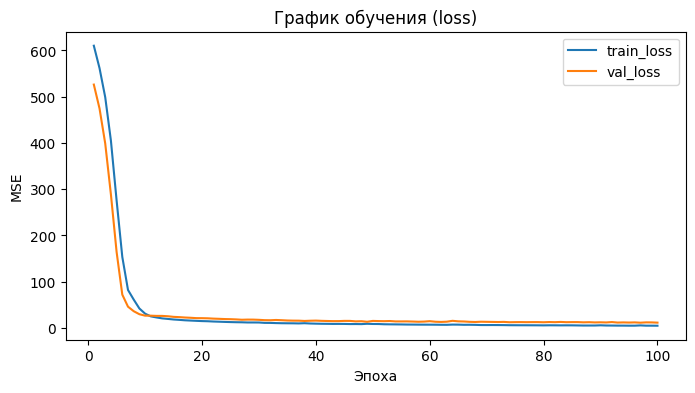

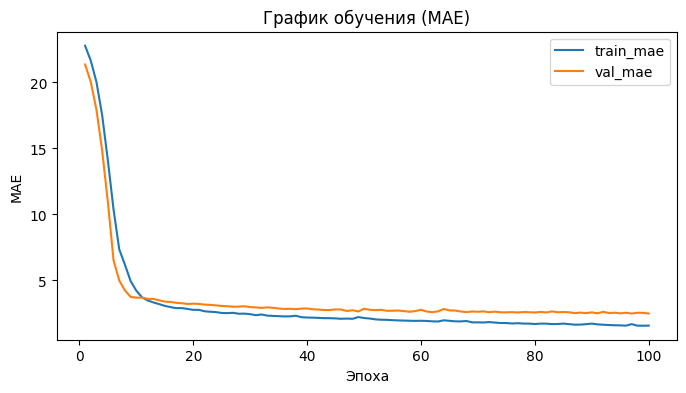

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8, 4))
N = len(history.history["loss"])
epochs_range = np.arange(1, N + 1)

plt.plot(epochs_range, history.history["loss"], label="train_loss")
plt.plot(epochs_range, history.history["val_loss"], label="val_loss")
plt.xlabel("Эпоха")
plt.ylabel("MSE")
plt.legend()
plt.title("График обучения (loss)")
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(epochs_range, history.history["mae"], label="train_mae")
plt.plot(epochs_range, history.history["val_mae"], label="val_mae")
plt.xlabel("Эпоха")
plt.ylabel("MAE")
plt.legend()
plt.title("График обучения (MAE)")
plt.show()


#### 1.9. Построение графического интерфейса в Gradio Проверка обученной модели пользовательскими данными

In [ ]:
import gradio as gr
import numpy as np

# названия признаков из описания датасета
feature_names = [
    "CRIM", "ZN", "INDUS", "CHAS", "NOX", "RM", "AGE",
    "DIS", "RAD", "TAX", "PTRATIO", "B", "LSTAT"
]

def predict_price(
    CRIM, ZN, INDUS, CHAS, NOX, RM, AGE,
    DIS, RAD, TAX, PTRATIO, B, LSTAT
):
    x = np.array([[CRIM, ZN, INDUS, CHAS, NOX, RM, AGE,
                   DIS, RAD, TAX, PTRATIO, B, LSTAT]])
    x_scaled = scaler.transform(x)
    price = model.predict(x_scaled)[0, 0]
    return f"Предсказанная цена: {price:.2f} (в условных единицах датасета)"

inputs = [
    gr.Number(label=name) for name in feature_names
]
output = gr.Textbox(label="Результат")

iface = gr.Interface(
    fn=predict_price,
    inputs=inputs,
    outputs=output,
    title="Предсказание цены жилья в Бостоне",
    description="Введите значения признаков для одной квартиры."
)


#### 2. Проверка обученной модели пользовательскими данными

In [ ]:
iface.launch()


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://a460614202729ba439.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## **Задание №2.Обучение модели ИНС для решения задачи классификации**



Порядок работы:

* 1. Собрать датасет из изображений, соответствующих не менее, чем 3 классам объектов (в
примере с пары были кошки, собаки и панды).


- 2. Для каждого класса должно быть собрано не менее 1000 изображений. Количество
изображений для каждого класса должно быть одинаковым.
Готовые датасеты можно скачать отсюда: https://www.kaggle.com/


- 3. Обучить модель глубокой нейронной сети для решения задачи классификации
изображений, по выбранным Вами классам. (В качестве примера приведён код с пары)
В конечном итоге Вы должны сохранить обученную модель для классификации
изображений, соответствующих тем классам, которые Вы выбрали, а затем воспользоваться этой моделью для предсказания классов на пользовательских изображениях.



> При выполнении заданий пробуйте использовать разные функции потерь,
методы оптимизации, функции активации и метрики ошибок.

### 1. Устанавливаем зависимости:

In [ ]:
# Импортируем LabelBinarizer для преобразования текстовых меток в векторы
# (например, "кошка" -> [1, 0, 0], "собака" -> [0, 1, 0], "панда" -> [0, 0, 1])
from sklearn.preprocessing import LabelBinarizer

# Импортируем train_test_split для разделения данных на обучающую и тестовую выборки
from sklearn.model_selection import train_test_split

# Импортируем classification_report для оценки качества классификации
from sklearn.metrics import classification_report

# Импортируем Sequential для создания последовательной модели нейронной сети
from keras.models import Sequential

# Импортируем Dense для создания плотных слоев нейронной сети
from keras.layers import Dense

# Импортируем SGD и Adam для оптимизации обучения нейронной сети
from keras.optimizers import SGD, Adam

# Импортируем paths из imutils для удобной работы с путями к изображениям
from imutils import paths

# Импортируем pyplot из matplotlib для визуализации данных
import matplotlib.pyplot as plt

# Импортируем numpy для работы с массивами данных
import numpy as np

# Импортируем random для генерации случайных чисел
import random

# Импортируем pickle для сериализации и десериализации данных
import pickle

# Импортируем cv2 для работы с изображениями
import cv2

# Импортируем os для работы с файловой системой
import os

# Импортируем cv2_imshow из google.colab.patches для отображения изображений в Colab
from google.colab.patches import cv2_imshow

### 2. Загружаем набор данных:

In [ ]:
# Скачиваем архив с набором данных
!curl -L -o flowers_dataset.zip \
  https://www.kaggle.com/api/v1/datasets/download/rahmasleam/flowers-dataset

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  218M  100  218M    0     0  94.1M      0  0:00:02  0:00:02 --:--:--  112M


In [ ]:
%%capture
# Распаковываем архив в папку dataset (%%capture подавляет вывод большого списка файлов)
!unzip flowers_dataset.zip -d dataset

### 3. Указываем путь к набору данных:

In [ ]:
dataset_path = "/content/dataset"

### 4. Загружаем набор данных и формируем общую выборку:

In [ ]:
from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import SGD, Adam

from imutils import paths

import matplotlib.pyplot as plt
import numpy as np
import random
import pickle
import cv2
import os

from google.colab.patches import cv2_imshow
import gradio as gr

image_paths = list(paths.list_images(dataset_path))
print(f"Найдено изображений: {len(image_paths)}")

# мешаем
random.shuffle(image_paths)

data = []
labels = []

for image_path in image_paths:
    image = cv2.imread(image_path)
    image = cv2.resize(image, (64, 64))
    data.append(image)

    label = image_path.split(os.path.sep)[-2]  # имя папки = класс
    labels.append(label)

data = np.array(data)
labels = np.array(labels)
print("Форма массива данных:", data.shape)
print("Количество классов:", len(np.unique(labels)))


Найдено изображений: 3670
Форма массива данных: (3670, 64, 64, 3)
Количество классов: 5


#### 4.1. Нормализуем данные:

Масштабируем интенсивности пикселей в диапазон [0, 1], а также преобразуем данные в массивы NumPy для повышения производительности


In [ ]:
# нормализация пикселей и приведение к float32
data = data.astype("float32") / 255.0

# разворачиваем 64x64x3 в вектор признаков
data = data.reshape((data.shape[0], -1))
print(data)
# one-hot для меток
lb = LabelBinarizer()
labels = lb.fit_transform(labels)

print("Форма признаков после развёртки:", data.shape)
print("Форма меток:", labels.shape)
print("Классы:", lb.classes_)


Форма признаков после развёртки: (3670, 12288)
Форма меток: (3670, 5)
Классы: ['daisy' 'dandelion' 'roses' 'sunflowers' 'tulips']


#### 4.2. Формируем обучающую и валидационную выборки:

Разделяем данные на обучающую и валидационную выборки, используя 75% данных для обучения и оставшиеся 25% для валидации

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    data,
    labels,
    test_size=0.25,
    random_state=42,
    stratify=labels
)
print("Обучающая выборка:", X_train.shape, y_train.shape)
print("Валидационная выборка:", X_val.shape, y_val.shape)


Обучающая выборка: (2752, 12288) (2752, 5)
Валидационная выборка: (918, 12288) (918, 5)


### 5. Создание модели:

#### 5.1. Определим архитектуру модели с помощью Keras:

In [ ]:
model_cls = Sequential()
model_cls.add(Dense(512, activation="relu", input_shape=(X_train.shape[1],)))
model_cls.add(Dense(256, activation="relu"))
model_cls.add(Dense(len(lb.classes_), activation="softmax"))
model_cls.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │     6,291,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,424,581 (24.51 MB)

 Trainable params: 6,424,581 (24.51 MB)

 Non-trainable params: 0 (0.00 B)

#### 5.2. Установим значение параметров скорости обучения и общего числа эпох


In [ ]:
speed = 0,001
epochs_count = 25
batch_size = 32

opt = Adam(learning_rate=speed)


#### 5.3. Компилируем модель:

In [ ]:
model_cls.compile(
    loss="categorical_crossentropy",
    optimizer=opt,
    metrics=["accuracy"]
)


### 6. Обучение модели искусственной нейронной сети:

#### 6.1. Добавим колбэки для сохранения лучшей модели по валидационной точности и остановки обучения, в случае, если модель перестала обучаться:

In [ ]:
from keras.callbacks import ModelCheckpoint, EarlyStopping

checkpoint = ModelCheckpoint(
    "best_model.h5",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

earlystop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

callbacks = [checkpoint, earlystop]


#### 6.2. Запустим процесс обучения модели:

In [ ]:
H = model_cls.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=epochs_count,
    batch_size=batch_size,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/25
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.2987 - loss: 5.1555
Epoch 1: val_accuracy improved from -inf to 0.38671, saving model to best_model.h5


86/86 ━━━━━━━━━━━━━━━━━━━━ 12s 113ms/step - accuracy: 0.2994 - loss: 5.1275 - val_accuracy: 0.3867 - val_loss: 1.4819
Epoch 2/25
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.4391 - loss: 1.3739
Epoch 2: val_accuracy did not improve from 0.38671
86/86 ━━━━━━━━━━━━━━━━━━━━ 11s 128ms/step - accuracy: 0.4392 - loss: 1.3737 - val_accuracy: 0.3867 - val_loss: 1.4119
Epoch 3/25
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.4668 - loss: 1.2702
Epoch 3: val_accuracy improved from 0.38671 to 0.39978, saving model to best_model.h5


86/86 ━━━━━━━━━━━━━━━━━━━━ 7s 80ms/step - accuracy: 0.4668 - loss: 1.2700 - val_accuracy: 0.3998 - val_loss: 1.3500
Epoch 4/25
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.5056 - loss: 1.1560
Epoch 4: val_accuracy improved from 0.39978 to 0.42593, saving model to best_model.h5


86/86 ━━━━━━━━━━━━━━━━━━━━ 8s 91ms/step - accuracy: 0.5055 - loss: 1.1562 - val_accuracy: 0.4259 - val_loss: 1.2874
Epoch 5/25
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.4891 - loss: 1.1918
Epoch 5: val_accuracy improved from 0.42593 to 0.43137, saving model to best_model.h5


86/86 ━━━━━━━━━━━━━━━━━━━━ 10s 89ms/step - accuracy: 0.4893 - loss: 1.1918 - val_accuracy: 0.4314 - val_loss: 1.3290
Epoch 6/25
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.5465 - loss: 1.0881
Epoch 6: val_accuracy improved from 0.43137 to 0.44989, saving model to best_model.h5


86/86 ━━━━━━━━━━━━━━━━━━━━ 7s 84ms/step - accuracy: 0.5466 - loss: 1.0882 - val_accuracy: 0.4499 - val_loss: 1.3375
Epoch 7/25
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.5498 - loss: 1.0843
Epoch 7: val_accuracy improved from 0.44989 to 0.46078, saving model to best_model.h5


86/86 ━━━━━━━━━━━━━━━━━━━━ 8s 94ms/step - accuracy: 0.5499 - loss: 1.0843 - val_accuracy: 0.4608 - val_loss: 1.3186
Epoch 8/25
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.5986 - loss: 0.9928
Epoch 8: val_accuracy did not improve from 0.46078
86/86 ━━━━━━━━━━━━━━━━━━━━ 7s 80ms/step - accuracy: 0.5983 - loss: 0.9932 - val_accuracy: 0.4063 - val_loss: 1.5237
Epoch 9/25
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.5961 - loss: 1.0269
Epoch 9: val_accuracy did not improve from 0.46078
86/86 ━━━━━━━━━━━━━━━━━━━━ 8s 88ms/step - accuracy: 0.5962 - loss: 1.0268 - val_accuracy: 0.4597 - val_loss: 1.2883
Epoch 9: early stopping
Restoring model weights from the end of the best epoch: 4.


#### 6.3. Загружаем лучшую модель:

In [ ]:
from keras.models import load_model

best_model = load_model("best_model.h5")


### 7. Оценка точности:

#### 7.1. Выведем отчет классификации

In [ ]:
preds = best_model.predict(X_val, batch_size=BS)
y_true = y_val.argmax(axis=1)
y_pred = preds.argmax(axis=1)

print(classification_report(y_true, y_pred, target_names=lb.classes_))


29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step
              precision    recall  f1-score   support

       daisy       0.38      0.59      0.46       158
   dandelion       0.55      0.28      0.37       225
       roses       0.53      0.38      0.44       160
  sunflowers       0.47      0.81      0.59       175
      tulips       0.47      0.32      0.38       200

    accuracy                           0.46       918
   macro avg       0.48      0.48      0.45       918
weighted avg       0.48      0.46      0.44       918



#### 7.2. Выведем матрицу ошибок

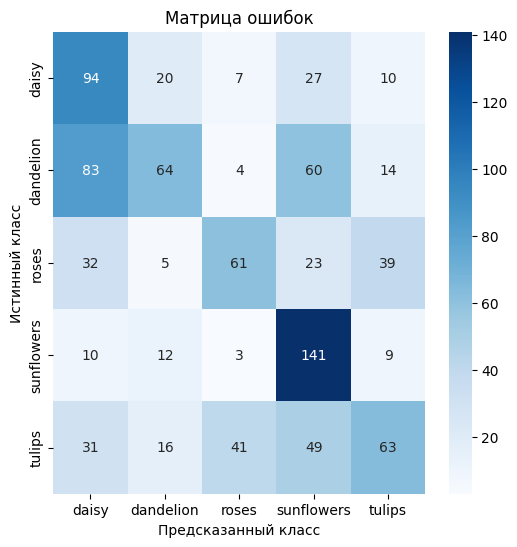

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=lb.classes_,
    yticklabels=lb.classes_
)
plt.xlabel("Предсказанный класс")
plt.ylabel("Истинный класс")
plt.title("Матрица ошибок")
plt.show()


#### 7.3. Отобразим график обучения

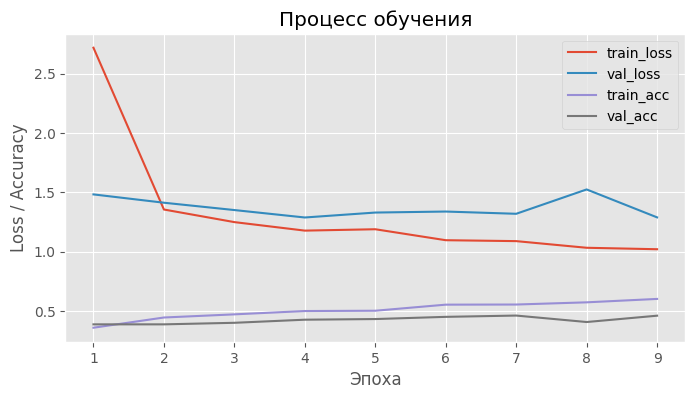

In [ ]:
plt.style.use("ggplot")
N = len(H.history["loss"])
epochs_range = np.arange(1, N + 1)

plt.figure(figsize=(8, 4))
plt.plot(epochs_range, H.history["loss"], label="train_loss")
plt.plot(epochs_range, H.history["val_loss"], label="val_loss")
plt.plot(epochs_range, H.history["accuracy"], label="train_acc")
plt.plot(epochs_range, H.history["val_accuracy"], label="val_acc")
plt.xlabel("Эпоха")
plt.ylabel("Loss / Accuracy")
plt.legend()
plt.title("Процесс обучения")
plt.show()


### 8. Сохранение модели и меток классов:

In [ ]:
best_model.save("classifier.h5")

with open("label_binarizer.pickle", "wb") as f:
    f.write(pickle.dumps(lb))


### 9. Проверка обученной модели пользовательскими данными:

#### 9.1. Импортируем необходимые библиотеки

In [ ]:
import gradio as gr
from keras.models import load_model
import pickle
import numpy as np
import cv2

model_infer = load_model("classifier.h5")
with open("label_binarizer.pickle", "rb") as f:
    lb_infer = pickle.load(f)

image_size = (64, 64)


#### 9.2. Реализуем функцию для предобработки входных данных в той же последовательности, что и при формировании обучающей выборки:

In [ ]:
def preprocess_image(img):
    # img — numpy-массив (H, W, 3), RGB
    img = cv2.resize(img, image_size)
    img = img.astype("float32") / 255.0
    img = img.reshape((1, -1))
    return img


#### 9.3. Определим функцию для осуществления прогноза по загруженной модели:

In [ ]:
def classify_image(img):
    x = preprocess_image(img)
    probs = model_infer.predict(x)[0]
    result = {cls: float(p) for cls, p in zip(lb_infer.classes_, probs)}
    return result


### 10. Визуализируем интерфейс и произведем классификацию:

In [ ]:
iface_cls = gr.Interface(
    fn=classify_image,
    inputs=gr.Image(type="numpy", label="Входное изображение"),
    outputs=gr.Label(num_top_classes=3, label="Предсказанные классы"),
    title="Классификация изображений",
    description="Загрузите изображение одного из обученных классов."
)

iface_cls.launch()


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://0132f6ab84932f8500.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
